<a href="https://colab.research.google.com/github/thuBv-123/Bai-tap-buoi-2/blob/main/Nhan%20dien%20van%20tay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# nhận diện vân tay

import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img,img_to_array,to_categorical
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Dropout
from keras.models import Sequential, load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir='/content/drive/MyDrive/PALM_TRAIN'
val_dir='/content/drive/MyDrive/PALM_VAL'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)


from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


val_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)
val_generator=val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)


model=Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[early_stop]
)

Found 88 images belonging to 3 classes.
Found 89 images belonging to 3 classes.
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.3367 - loss: 4.3281 - val_accuracy: 0.3258 - val_loss: 3.6932
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.2978 - loss: 2.7297 - val_accuracy: 0.3258 - val_loss: 1.1274
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.3490 - loss: 1.0852 - val_accuracy: 0.3371 - val_loss: 1.1094
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.2557 - loss: 1.0994 - val_accuracy: 0.2022 - val_loss: 1.1186
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.4617 - loss: 1.0741 - val_accuracy: 0.2360 - val_loss: 1.1464
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.4522 - loss: 1.0531 - val_accuracy: 0.2247 - val_loss: 1.2460
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.4541 - loss: 1.0354 - val_accuracy: 0.1461 - val_loss: 1.2569
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


Text(0.5, 1.0, ' Đây là vân tay của :Thomas')

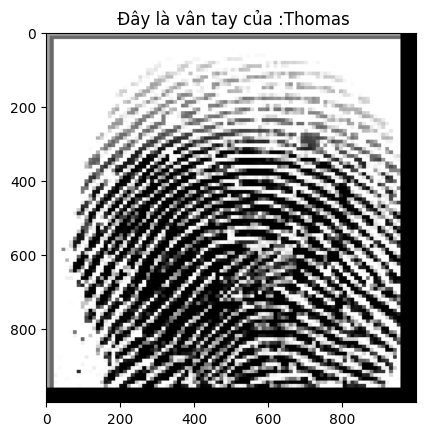

In [9]:
img = load_img('/content/vân tay 104.jpg', target_size=(1000, 1000))
plt.imshow(img)
img = img.resize((224, 224))
img_array = img_to_array(img) / 255.0
img_array = img_array.reshape(1, 224, 224, 3)
prediction = model.predict(img_array)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
plt.title(f' Đây là vân tay của :{predicted_class}')